In [1]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [28]:
# Loading train, validation and test splits
X_train_df = pd.read_csv("Activity_Scaled_Train.csv")
X_val_df   = pd.read_csv("Activity_Scaled_Validation.csv")
X_test_df  = pd.read_csv("Activity_Scaled_Test.csv")

X_train = X_train_df.drop(columns=["Activity"])
y_train = X_train_df["Activity"]

X_val   = X_val_df.drop(columns=["Activity"])
y_val   = X_val_df["Activity"]

X_test  = X_test_df.drop(columns=["Activity"])
y_test  = X_test_df["Activity"]

print("Dataset loaded successfully!")
print(f"Train size     : {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size      : {X_test.shape}")
print(f"\nClasses: {y_train.unique()}")

Dataset loaded successfully!
Train size     : (6179, 561)
Validation size: (2060, 561)
Test size      : (2060, 561)

Classes: ['WALKING_UPSTAIRS' 'WALKING' 'SITTING' 'LAYING' 'WALKING_DOWNSTAIRS'
 'STANDING']


In [29]:
def print_metrics(y_true, y_pred, dataset_name="Test"):
    """
    Prints confusion matrix and classification metrics
    for multiclass classification.
    """
    cm       = confusion_matrix(y_true, y_pred)
    acc      = accuracy_score(y_true, y_pred)
    prec_mac = precision_score(y_true, y_pred, average='macro',  zero_division=0)
    prec_mic = precision_score(y_true, y_pred, average='micro',  zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',  zero_division=0)
    rec_mic  = recall_score(y_true, y_pred,    average='micro',  zero_division=0)
    f1_mac   = f1_score(y_true, y_pred,        average='macro',  zero_division=0)
    f1_mic   = f1_score(y_true, y_pred,        average='micro',  zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {dataset_name} Results")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(cm)
    print(f"\nAccuracy          : {acc:.4f}")
    print(f"Precision (Macro) : {prec_mac:.4f}")
    print(f"Precision (Micro) : {prec_mic:.4f}")
    print(f"Recall    (Macro) : {rec_mac:.4f}")
    print(f"Recall    (Micro) : {rec_mic:.4f}")
    print(f"F1-Score  (Macro) : {f1_mac:.4f}")
    print(f"F1-Score  (Micro) : {f1_mic:.4f}")

    return acc

print("Helper function defined!")

Helper function defined!


In [42]:
print("Training Logistic Regression on scaled data...")

logistic_reg = LogisticRegression(solver='liblinear', max_iter=1000)
logistic_reg.fit(X_train, y_train)

print("Training done!")

y_val_pred_lr  = logistic_reg.predict(X_val)
y_test_pred_lr = logistic_reg.predict(X_test)

Training Logistic Regression on scaled data...
Training done!


In [44]:
print("=" * 50)
print("TASK 2.1: LOGISTIC REGRESSION - SCALED DATA")
print("=" * 50)

acc_lr_val  = print_metrics(y_val, y_val_pred_lr, "Validation")
acc_lr_test = print_metrics(y_test, y_test_pred_lr, "Test")

TASK 2.1: LOGISTIC REGRESSION - SCALED DATA

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 342  13   0   0   0]
 [  0  19 362   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   0 280   1]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9830
Precision (Macro) : 0.9838
Precision (Micro) : 0.9830
Recall    (Macro) : 0.9839
Recall    (Micro) : 0.9830
F1-Score  (Macro) : 0.9839
F1-Score  (Micro) : 0.9830

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 340  16   0   0   0]
 [  0  13 368   0   0   0]
 [  0   0   0 344   0   0]
 [  0   1   0   0 280   0]
 [  0   0   0   4   1 304]]

Accuracy          : 0.9830
Precision (Macro) : 0.9840
Precision (Micro) : 0.9830
Recall    (Macro) : 0.9835
Recall    (Micro) : 0.9830
F1-Score  (Macro) : 0.9837
F1-Score  (Micro) : 0.9830


In [45]:
# Task 1.2 - SVM with Linear Kernel
print("Training SVM with Linear Kernel on scaled data...")

linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train, y_train)

print("Training done!")

y_val_pred_lin  = linear_svm.predict(X_val)
y_test_pred_lin = linear_svm.predict(X_test)

Training SVM with Linear Kernel on scaled data...
Training done!


In [46]:
print("=" * 50)
print("TASK 1.2: SVM (LINEAR KERNEL) - SCALED DATA")
print("=" * 50)

acc_lin_val  = print_metrics(y_val, y_val_pred_lin, "Validation")
acc_lin_test = print_metrics(y_test, y_test_pred_lin, "Test")

TASK 1.2: SVM (LINEAR KERNEL) - SCALED DATA

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 339  15   0   0   1]
 [  0  21 360   0   0   0]
 [  0   0   0 344   1   0]
 [  0   0   0   1 280   0]
 [  0   0   0   2   1 306]]

Accuracy          : 0.9796
Precision (Macro) : 0.9804
Precision (Micro) : 0.9796
Recall    (Macro) : 0.9806
Recall    (Micro) : 0.9796
F1-Score  (Macro) : 0.9805
F1-Score  (Micro) : 0.9796

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 344  12   0   0   0]
 [  0  14 367   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   3   1 305]]

Accuracy          : 0.9850
Precision (Macro) : 0.9857
Precision (Micro) : 0.9850
Recall    (Macro) : 0.9855
Recall    (Micro) : 0.9850
F1-Score  (Macro) : 0.9856
F1-Score  (Micro) : 0.9850


In [47]:
# Task 1.3 - SVM with Polynomial Kernel

print("Training SVM with Polynomial Kernel for different degrees...")

best_degree  = None
best_val_acc = 0
degree_val_accuracies = {}

for degree in [2, 3, 4, 5]:
    poly_svm = SVC(kernel='poly', degree=degree, C=1.0, gamma='scale')
    poly_svm.fit(X_train, y_train)
    
    val_acc = poly_svm.score(X_val, y_val)
    degree_val_accuracies[degree] = val_acc
    print(f"Degree={degree}, Validation Accuracy={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_degree  = degree

print(f"\nBest Degree: {best_degree} with Validation Accuracy: {best_val_acc:.4f}")

Training SVM with Polynomial Kernel for different degrees...
Degree=2, Validation Accuracy=0.9738
Degree=3, Validation Accuracy=0.9655
Degree=4, Validation Accuracy=0.9364
Degree=5, Validation Accuracy=0.9194

Best Degree: 2 with Validation Accuracy: 0.9738


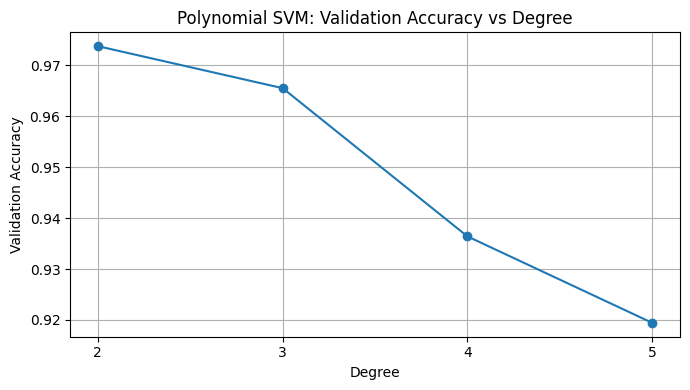

In [48]:
# plot validation accuracy vs degree
plt.figure(figsize=(7, 4))
plt.plot(list(degree_val_accuracies.keys()), list(degree_val_accuracies.values()), marker='o')
plt.title('Polynomial SVM: Validation Accuracy vs Degree')
plt.xlabel('Degree')
plt.ylabel('Validation Accuracy')
plt.xticks([2, 3, 4, 5])
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# train again with the best degree and evaluate on test data
print(f"Training final Polynomial SVM with best degree = {best_degree}...")

best_poly_svm = SVC(kernel='poly', degree=best_degree, C=1.0, gamma='scale')
best_poly_svm.fit(X_train, y_train)

y_val_pred_poly  = best_poly_svm.predict(X_val)
y_test_pred_poly = best_poly_svm.predict(X_test)

print("Done!")

Training final Polynomial SVM with best degree = 2...
Done!


In [50]:
print("=" * 55)
print(f"TASK 1.3: SVM (POLY KERNEL, DEGREE={best_degree}) - SCALED DATA")
print("=" * 55)

print("\nValidation Accuracies for all degrees:")
for d, acc in degree_val_accuracies.items():
    marker = " <-- best" if d == best_degree else ""
    print(f"  Degree {d}: {acc:.4f}{marker}")

acc_poly_val  = print_metrics(y_val, y_val_pred_poly, "Validation (Best Degree)")
acc_poly_test = print_metrics(y_test, y_test_pred_poly, "Test (Best Degree)")

TASK 1.3: SVM (POLY KERNEL, DEGREE=2) - SCALED DATA

Validation Accuracies for all degrees:
  Degree 2: 0.9738 <-- best
  Degree 3: 0.9655
  Degree 4: 0.9364
  Degree 5: 0.9194

  Validation (Best Degree) Results
Confusion Matrix:
[[388   1   0   0   0   0]
 [  1 333  20   0   0   1]
 [  0  20 361   0   0   0]
 [  0   1   0 343   1   0]
 [  0   1   0   2 276   2]
 [  0   1   0   0   3 305]]

Accuracy          : 0.9738
Precision (Macro) : 0.9746
Precision (Micro) : 0.9738
Recall    (Macro) : 0.9744
Recall    (Micro) : 0.9738
F1-Score  (Macro) : 0.9745
F1-Score  (Micro) : 0.9738

  Test (Best Degree) Results
Confusion Matrix:
[[388   0   1   0   0   0]
 [  1 336  19   0   0   0]
 [  0  19 362   0   0   0]
 [  0   0   0 344   0   0]
 [  0   1   0   0 273   7]
 [  0   3   0   0   0 306]]

Accuracy          : 0.9752
Precision (Macro) : 0.9764
Precision (Micro) : 0.9752
Recall    (Macro) : 0.9755
Recall    (Micro) : 0.9752
F1-Score  (Macro) : 0.9759
F1-Score  (Micro) : 0.9752


In [51]:
# Task 1.4 - SVM with RBF Kernel
print("Training SVM with RBF (Gaussian) Kernel...")

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train, y_train)

print("Done!")

y_val_pred_rbf  = rbf_svm.predict(X_val)
y_test_pred_rbf = rbf_svm.predict(X_test)

Training SVM with RBF (Gaussian) Kernel...
Done!


In [52]:
print("=" * 50)
print("TASK 1.4: SVM (RBF KERNEL) - SCALED DATA")
print("=" * 50)

acc_rbf_val  = print_metrics(y_val, y_val_pred_rbf, "Validation")
acc_rbf_test = print_metrics(y_test, y_test_pred_rbf, "Test")

TASK 1.4: SVM (RBF KERNEL) - SCALED DATA

  Validation Results
Confusion Matrix:
[[386   0   0   0   3   0]
 [  1 335  18   0   0   1]
 [  0  19 362   0   0   0]
 [  0   0   0 342   3   0]
 [  0   0   0   1 280   0]
 [  0   0   0   0   1 308]]

Accuracy          : 0.9772
Precision (Macro) : 0.9776
Precision (Micro) : 0.9772
Recall    (Macro) : 0.9784
Recall    (Micro) : 0.9772
F1-Score  (Macro) : 0.9780
F1-Score  (Micro) : 0.9772

  Test Results
Confusion Matrix:
[[388   0   0   0   1   0]
 [  0 341  15   0   0   0]
 [  0  21 360   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 281   0]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9811
Precision (Macro) : 0.9820
Precision (Micro) : 0.9811
Recall    (Macro) : 0.9823
Recall    (Micro) : 0.9811
F1-Score  (Macro) : 0.9821
F1-Score  (Micro) : 0.9811


In [53]:
# Task 1.5 - Comparison table for all classifiers on original data

comparison_val = {
    'Classifier':          ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Validation Accuracy': [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
}

comparison_test = {
    'Classifier':      ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Test Accuracy':   [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]
}

df_val  = pd.DataFrame(comparison_val)
df_test = pd.DataFrame(comparison_test)

print("Validation Accuracy Comparison (Original Data):")
print(df_val.to_string(index=False))

print("\nTest Accuracy Comparison (Original Data):")
print(df_test.to_string(index=False))

Validation Accuracy Comparison (Original Data):
         Classifier  Validation Accuracy
Logistic Regression             0.983010
         SVM Linear             0.979612
     SVM Poly (d=2)             0.973786
            SVM RBF             0.977184

Test Accuracy Comparison (Original Data):
         Classifier  Test Accuracy
Logistic Regression       0.983010
         SVM Linear       0.984951
     SVM Poly (d=2)       0.975243
            SVM RBF       0.981068


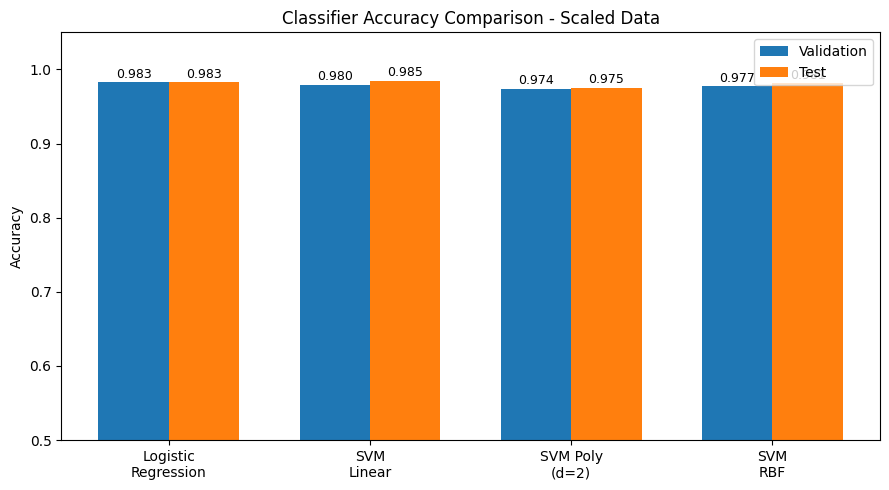


Discussion:
Best classifier on Validation: Logistic Regression (0.9830)
Best classifier on Test:       SVM Linear (0.9850)


In [57]:
classifiers = ['Logistic\nRegression', 'SVM\nLinear', f'SVM Poly\n(d={best_degree})', 'SVM\nRBF']
val_accs  = [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
test_accs = [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]

x = np.arange(len(classifiers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Validation')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test')

ax.set_title('Classifier Accuracy Comparison - Scaled Data')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.legend()
ax.set_ylim(0.5, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_val_clf  = classifiers[np.argmax(val_accs)].replace('\n', ' ')
best_test_clf = classifiers[np.argmax(test_accs)].replace('\n', ' ')
print(f"\nDiscussion:")
print(f"Best classifier on Validation: {best_val_clf} ({max(val_accs):.4f})")
print(f"Best classifier on Test:       {best_test_clf} ({max(test_accs):.4f})")
